<a href="https://colab.research.google.com/github/yetiwannacode/TASK_MNIST/blob/main/Digit_Classifier_Task1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## MNIST Digit classifier-- Ayush


##Loading and Exploring the MNIST Dataset
Before training the model, I am downloading the dataset and visualizing sample images to understand the input format.


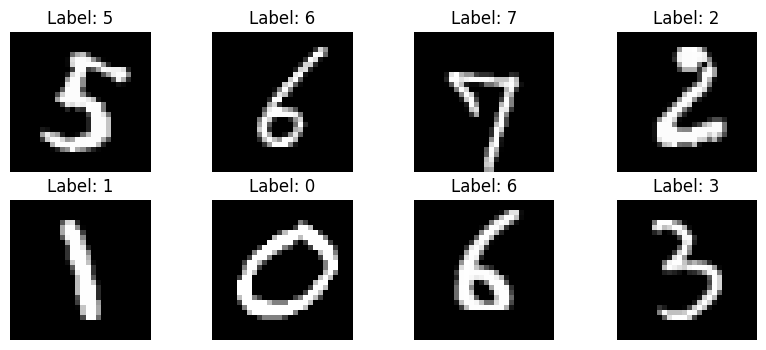

In [ ]:
import torch
from torchvision import datasets, transforms #for loading data and transforms
from torch.utils.data import DataLoader #for batching
import matplotlib.pyplot as plt #for plotting

# Transform: Converting to tensor and normalizing
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Downloading MNIST
trainset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
trainloader = DataLoader(trainset, batch_size=64, shuffle=True) #chose small batch

# Display a few images
images, labels = next(iter(trainloader))

plt.figure(figsize=(10,4))
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(images[i][0], cmap='gray')
    plt.title(f"Label: {labels[i].item()}")
    plt.axis('off')
plt.show()


## Building the Neural Network
I will define a simple feedforward neural network using PyTorch's "nn.Module". This model will have 3 fully connected layers.


In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class DigitClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28*28, 128)  # Input layer
        self.fc2 = nn.Linear(128, 64)     # Hidden layer
        self.fc3 = nn.Linear(64, 10)      # Output layer (10 classes)

    def forward(self, x):
        x = x.view(x.shape[0], -1)        # Flatten
        x = F.relu(self.fc1(x))           #Using RELu to apply non linearity
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

model = DigitClassifier()
print(model)


DigitClassifier(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
)


## Training the Neural Network
I will now train the model using the MNIST training data. I will use cross-entropy loss and the Adam optimizer for efficient learning.


In [ ]:
import torch.nn as nn
import torch.optim as optim

# Defining loss function and optimizer
criterion = nn.CrossEntropyLoss() #already includes softmax
optimizer = optim.Adam(model.parameters(), lr=0.003) #could have used SGD but needs more tuning

# Training loop
epochs = 5
for epoch in range(epochs):
    running_loss = 0
    for images, labels in trainloader:
        optimizer.zero_grad()           # Clear gradients
        output = model(images)          # Forward pass
        loss = criterion(output, labels)  # Compute loss
        loss.backward()                 # Backpropagation
        optimizer.step()                # Update weights
        running_loss += loss.item()

    print(f"Epoch {epoch+1} - Training loss: {running_loss/len(trainloader):.4f}") #if throughout epochs our training loss decreases steadily its learning well


Epoch 1 - Training loss: 0.3526
Epoch 2 - Training loss: 0.1748
Epoch 3 - Training loss: 0.1397
Epoch 4 - Training loss: 0.1227
Epoch 5 - Training loss: 0.1125


## Testing and Visualizing Model Predictions
I will now evaluate the model on the test set and visualize how well it performs by comparing predictions against actual labels.


In [ ]:
# Load test data
testset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
testloader = DataLoader(testset, batch_size=64, shuffle=False)

# Check accuracy
correct = 0
total = 0

with torch.no_grad():
    for images, labels in testloader:
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Accuracy: {100 * correct / total:.2f}%")


Test Accuracy: 96.28%


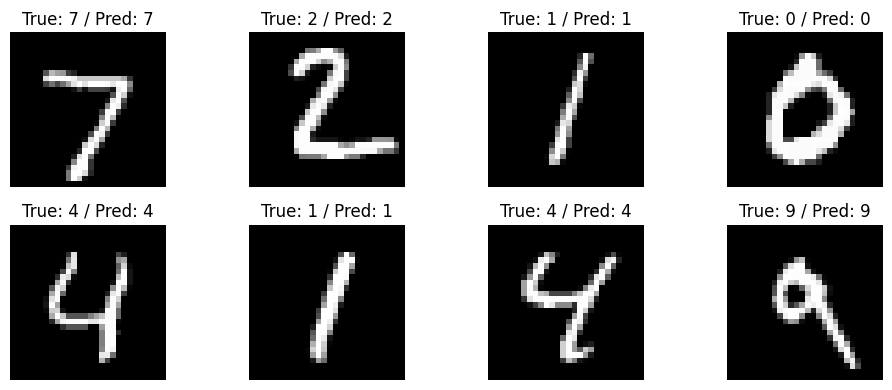

In [ ]:
# Visualize predictions
import matplotlib.pyplot as plt

images, labels = next(iter(testloader))
outputs = model(images)
_, preds = torch.max(outputs, 1)

plt.figure(figsize=(10,4))
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(images[i][0], cmap='gray')
    plt.title(f"True: {labels[i]} / Pred: {preds[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()


## Final Observations:

- The model achieved an average accuracy of **95.96%** on the test set after just **5 epochs** and 4 test runs.
- It performs well in recognizing most handwritten digits.
- Further improvements could include using a CNN or training longer with regularization.
- This project really helped me dive into the world of NN's and Deep learning and learn about so many things starting from the structure of NN to loss functions and optimizers

Thank you for reviewing my project!
